In [1]:
import os 
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
data = "datas\\names.txt" 
data_path = os.path.join(os.getcwd(),data)

In [3]:
words = open(data_path,"r").read().splitlines()
type(words)

list

In [4]:
chars   = sorted(list(set("".join(words))))
stoi    = {s:i+1 for i,s in enumerate(chars)} 
stoi["."] = 0
itos    = {s:i for i,s in sorted((stoi.items()))}

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
print(len(words))
print(max(len(word) for word in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


## Building Dataset

In [7]:
def build_dataset(dataset:list=None,block_size:int=3):

    X,Y = [],[]
    for word in dataset:

        context = [0] * block_size
        for char in word +".":
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx] # crop and append
    
    X = torch.tensor(X,device="cuda")
    Y = torch.tensor(Y,device="cuda") 
    print(X.shape,Y.shape)
    return X,Y


random.seed(42)
random.shuffle(words,random=random.seed(42))
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

x_train,y_train = build_dataset(words[:n1])
x_val,y_val     = build_dataset(words[n1:n2])
x_test,y_test   = build_dataset(words[n2:]) 


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
for x,y in zip(x_train[:20],y_train[:20]):
    print("".join(itos[idx.item()] for idx in x),"--->",itos[y.item()])

... ---> y
..y ---> u
.yu ---> h
yuh ---> e
uhe ---> n
hen ---> g
eng ---> .
... ---> d
..d ---> i
.di ---> o
dio ---> n
ion ---> d
ond ---> r
ndr ---> e
dre ---> .
... ---> x
..x ---> a
.xa ---> v
xav ---> i
avi ---> e


## Create Neural Netowrk Model

In [9]:
## The Model that created before
class Linear:
    def __init__(self,fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in,fan_out)  ,device="cuda") / fan_in ** 0.5      # note: kaiming init
        self.bias   = torch.zeros(fan_out           ,device="cuda") if bias else None    

    def __call__(self,x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias 
        return self.out         
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
## --------------------------------Batch_Normalization-----------------------------------------------##     

class BatchNormalization:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps            = eps 
        self.momentum       = momentum
        self.training       = True
        # parameter (trained with backprop)
        self.gamma          = torch.ones(dim,device="cuda:0")
        self.beta           = torch.zeros(dim,device="cuda:0")
        # buffer parameter  (trained with running "momemtum update")
        self.runnnig_mean   = torch.zeros(dim,device="cuda:0")
        self.runnnig_var    = torch.ones(dim,device="cuda:0")

    def __call__(self, x):
        #calculate forward pass 
        if self.training:
            x_mean          = torch.mean(x,dim=0,keepdim=True)              # batch mean 
            x_var           = torch.var(x,dim=0,keepdim=True,unbiased=True) # batch varience
        else:
            x_mean          = self.runnnig_mean
            x_var           = self.runnnig_var

        x_hat               = (x - x_mean) / torch.sqrt(x_var + self.eps)   # nomralize to unit varience 
        self.out            = self.gamma * x_hat + self.beta                
        # update the buffer         
        if self.training:
            with torch.no_grad():
                self.runnnig_mean   = (1 - self.momentum) * self.runnnig_mean + self.momentum * x_mean
                self.runnnig_var    = (1 - self.momentum) * self.runnnig_var  + self.momentum * x_var
        return self.out
    
    def parameters(self):
        return [self.gamma,self.beta]
    
## --------------------------------Tanh()-----------------------------------------------##     

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out 
    def parameters(self):
        return [] 

In [10]:
torch.manual_seed(42);

In [11]:
n_embd      = 10
n_hidden    = 200
block_size  = 3
vocab_size  = len(itos)

C           = torch.randn((vocab_size,n_embd),device="cuda")
layers      = [Linear(n_embd*block_size,n_hidden,bias=False),BatchNormalization(dim=n_hidden),Tanh(),
               Linear(n_hidden,vocab_size),]

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

parameters      = [C] + [para for layer in layers for para in layer.parameters()]
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 12097


In [13]:
n_iter      = 50000
batch_size  = 32
loss_i      = []

for i in range(n_iter):

    # mini batch
    ix              = torch.randint(0,x_train.shape[0],(batch_size,),device="cuda") # 32 numbers between 0 to 182437==>> shape (32,)
    x_batch,y_batch = x_train[ix],y_train[ix] 
    # forward pass 
    emb         = C[x_batch]                # (32,3,10)
    x           = emb.view(emb.shape[0],-1) # (32,30)
    for layer in layers:
        x = layer(x)                        # output ==>> (32 * 27) ==>> (batch_size * vocab_size)
    loss = F.cross_entropy(x,y_batch)       # expect initial loss   ==>> (1/27) = 
    #backward pass 
    for layer in layers:
        layer.out.retain_grad() 

    for para in parameters:
        para.grad = None
    loss.backward()
    # update the parameters
    lr = 0.1 if n_iter < 100000 else 0.01 # step learning rate decay 
    for para in parameters:
        para.data += - lr * para.grad

    # track loss 
    if i % 10000 == 0:
        print(f"{i:7d}/{n_iter:7d} :   {loss.item():.4f}")
    loss_i.append(loss.item())

      0/  50000 :   3.3078
  10000/  50000 :   2.5182
  20000/  50000 :   2.3602
  30000/  50000 :   2.1772
  40000/  50000 :   1.7950


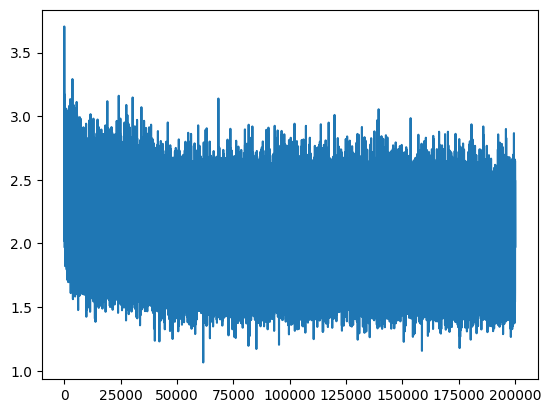

In [89]:
plt.plot(loss_i);

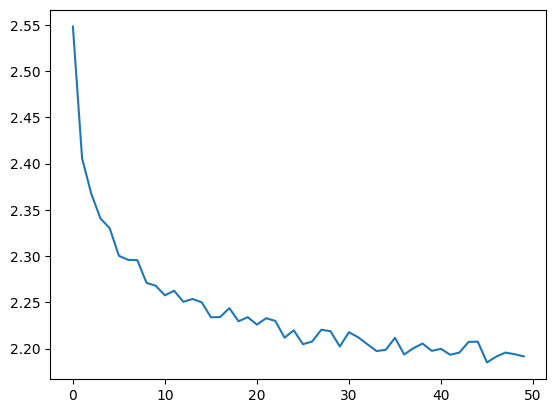

In [14]:
plt.plot(torch.tensor(loss_i).view(-1,1000).mean(1))

In [13]:
## put layers into eval model (needed for batchnorm especially)
for layer in layers:
    layer.training = False 

## prevent these weights from being updated during training.

### Freezing Layers for Transfer Learning,Fine-Tuning and Evaluation 

#### layer.training = False comes into play:

- Freezing Base Layers: "freeze" the weights (parameters) of the pre-trained model's earlier layers. These layers have already captured general-purpose features that are likely transferable to your new task.
    **By setting layer.training = False**,

**you prevent these weights from being updated during training.**

- Fine-Tuning with New Layers: You then add new layers on top of the frozen pre-trained model. These new layers are responsible for learning task-specific features relevant to your dataset. Since they're trainable, their weights are updated during training.

Benefits:

- Leveraging Pre-trained Knowledge: You capitalize on the pre-trained features already learned by the base model, saving training time and potentially improving performance.
- Preventing Overfitting: By not adjusting the well-learned weights of the base model, you can help to reduce the risk of overfitting to the new dataset, where the model memorizes training data too much and performs poorly on unseen data.
Faster Training: Since you're not training the weights in the frozen layers, training becomes more efficient.

In [14]:
@torch.no_grad()       # this decorator disable gradient tracking, (no need to calulate during evaluation)
def split_loss(split):
    x,y = {
        "train" : (x_train,y_train),
        "val"   : (x_val,y_val),
        "test"  : (x_test,y_test)
    }[split]
    emb         = C[x]                      # (N,block_size,n_emb)
    x           = emb.view(emb.shape[0],-1) # (number_of_dataset, block_size * n_emb) (N, 3 * 10)
    for layer in layers:
        x = layer(x)
    loss        = F.cross_entropy(x,y) 
    print(split,loss.item())

split_loss("train")
split_loss("val")


train 3.2976953983306885
val 3.297905683517456


In [15]:
## sample from the model 
for _ in range(20):
    out     = []
    context = [0] * block_size 
    while True:
        # forward pass the neural net 
        emb = C[torch.tensor([context])]    # (1,block_size,n_emb)
        x   = emb.view(emb.shape[0],-1)     # (1,block_size*n_emb)
        for layer in layers:
            x = layer(x)
        logits  = x                         # (1,n_vocab)
        probs   = F.softmax(x,dim=1)
        # sample from distribution 
        ix = torch.multinomial(probs,num_samples=1).item()
        # shift the context window and track the sample 
        context = context[1:] + [ix] 
        out.append(ix)
        if ix ==0:
            break       # break the loop when . is predicted 
    print(''.join(itos[i] for i in out))

tajokyvgrzppeopkgbr.
eqwskmniriphqiojfibjxqsvf.
btwupwhoqxgzmiirwxifbqoionyuqucicpmops.
i.
smqolvhqsugoqmkfzwltv.
vlhcvqdstwdnzqorkeezuruedg.
hzdikhtptr.
nfpzykyrqjytrjyjjnfwkzgtaoprzzrzrrojdgceenn.
qqzligtgjpfvdvmarifpkzp.
vgdcxklcncofrnclekelcfkgpplrgywuzjqckspcnpsjwzgkbcvxkdgacqotnlzxcrqzdkgvckzkl.
.
jcxa.
socssekuhdvqnf.
ejpmacbgm.
tiewwplkfxsgkmplduljhqyxztuepoyabrcvelvvkjyabzqmkkhnv.
vynpsetlgsldge.
hdhez.
paixoikvqjnasoxsufjtwnxapwybftyzylaeicmrhrphmllgpugsxuguuflgcbbuusnzor.
hsneawwrwuisfwgrmnqgftlowzhgmcllhfmdmjdijzvhqclkeabbxikunojephk.
epftdrmibrzpxubijf.


## 1.Fix the loss

In [13]:
## The Model that created before
class Linear:
    def __init__(self,fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in,fan_out)  ,device="cuda") / fan_in ** 0.5      # note: kaiming init
        self.bias   = torch.zeros(fan_out           ,device="cuda") if bias else None    

    def __call__(self,x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias 
        return self.out         
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
## --------------------------------Batch_Normalization-----------------------------------------------##     

class BatchNormalization:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps            = eps 
        self.momentum       = momentum
        self.training       = True
        # parameter (trained with backprop)
        self.gamma          = torch.ones(dim,device = "cuda:0")
        self.beta           = torch.zeros(dim,device= "cuda:0")
        # buffer parameter  (trained with running "momemtum update")
        self.runnnig_mean   = torch.zeros(dim,device= "cuda:0")
        self.runnnig_var    = torch.ones(dim,device = "cuda:0")

    def __call__(self, x):
        #calculate forward pass 
        if self.training:
            x_mean          = torch.mean(x,dim=0,keepdim=True)              # batch mean 
            x_var           = torch.var(x,dim=0,keepdim=True,unbiased=True) # batch varience
        else:
            x_mean          = self.runnnig_mean
            x_var           = self.runnnig_var

        x_hat               = (x - x_mean) / torch.sqrt(x_var + self.eps)   # nomralize to unit varience 
        self.out            = self.gamma * x_hat + self.beta                
        # update the buffer         
        if self.training:
            with torch.no_grad():
                self.runnnig_mean   = (1 - self.momentum) * self.runnnig_mean + self.momentum * x_mean
                self.runnnig_var    = (1 - self.momentum) * self.runnnig_var  + self.momentum * x_var
        return self.out
    
    def parameters(self):
        return [self.gamma,self.beta]
    
## --------------------------------Tanh()-----------------------------------------------##     

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out 
    
    def parameters(self):
        return [] 

## --------------------------------Embedding()-----------------------------------------------##     
class Embeddings:
    def __init__(self,num_emb,emb_dim):
        self.weight = torch.rand((num_emb,emb_dim),device=device)

    def __call__(self,IX):    
        self.out = self.weight[IX]    
        return self.out 
    
    def parameters(self):
        return [self.weight]
    
## --------------------------------Flatten()-----------------------------------------------##     
class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0],-1)
        return self.out 
    def parameters(self):
        return []

## --------------------------------Sequential()-----------------------------------------------##     
class Sequential:
    def __init__(self,layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x       = layer(x)
        self.out    = x
        return self.out 
    def parameters(self):
        return [para in layer in self.layers for para in layer.parameters()]  

In [14]:
torch.manual_seed(42);

## Replacing the code 

In [15]:
n_embd      = 10
n_hidden    = 200
block_size  = 3
vocab_size  = len(itos)

#C          = torch.randn((vocab_size,n_embd),device="cuda")
#emb        = C[torch.tensor([context])]    # (1,block_size,n_emb)
#x          = emb.view(emb.shape[0],-1)     # (1,block_size*n_emb)

#can replace the above step with object 'Embeddings' & 'Flatten'

layers      = [
    Embeddings(vocab_size,n_embd),
    Flatten(),
    Linear(n_embd*block_size,n_hidden,bias=False),BatchNormalization(dim=n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),]

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

# parameters      = [C] + [para for layer in layers for para in layer.parameters()] remove [C]

parameters      = [para for layer in layers for para in layer.parameters()]
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 12097


In [16]:
n_iter      = 50000
batch_size  = 32
loss_i      = []

for i in range(n_iter):

    # mini batch
    ix              = torch.randint(0,x_train.shape[0],(batch_size,),device="cuda") # 32 numbers between 0 to 182437==>> shape (32,)
    x_batch,y_batch = x_train[ix],y_train[ix] 
    # forward pass 
    
    #emb            = C[x_batch]                # (32,3,10)    we can replace this step, 
    #x              = emb.view(emb.shape[0],-1) # (32,30)      we can repalce this step,

    x   = x_batch   # we only need this, because can directly pass into layers, 
    for layer in layers:
        x = layer(x)                        # output ==>> (32 * 27) ==>> (batch_size * vocab_size)
    loss = F.cross_entropy(x,y_batch)       # expect initial loss   ==>> (1/27) = 
    #backward pass 
    for layer in layers:
        layer.out.retain_grad() 

    for para in parameters:
        para.grad = None
    loss.backward()
    # update the parameters
    lr = 0.1 if n_iter < 100000 else 0.01 # step learning rate decay 
    for para in parameters:
        para.data += - lr * para.grad

    # track loss 
    if i % 10000 == 0:
        print(f"{i:7d}/{n_iter:7d} :   {loss.item():.4f}")
    loss_i.append(loss.item())
    break

      0/  50000 :   3.2913


#### Sequential 

Sequential is container, Module will be added to it in order they are passed in the constructor. 

In [15]:
class Sequential:
    def __init__(self,layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x       = layer(x)
        self.out    = x
        return self.out 
    def parameters(self):        
        return [para for layer in self.layers for para in layer.parameters()]

## Replacing the complex code with Sequential code 

In [18]:
n_embd      = 10
n_hidden    = 200
block_size  = 3
vocab_size  = len(itos)


model      = Sequential([Embeddings(vocab_size,n_embd),Flatten(),
                        Linear(n_embd*block_size,n_hidden,bias=False),BatchNormalization(dim=n_hidden),Tanh(),
                        Linear(n_hidden,vocab_size),])

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

parameters      = model.parameters()
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 12097


In [20]:
n_iter      = 200000
batch_size  = 32
loss_i      = []

for i in range(n_iter):

    # mini batch
    ix              = torch.randint(0,x_train.shape[0],(batch_size,),device="cuda") # 32 numbers between 0 to 182437==>> shape (32,)
    x_batch,y_batch = x_train[ix],y_train[ix] 
    # forward pass 
    x       = x_batch   # we only need this, because can directly pass into layers, 
    logits  = model(x)
    loss    = F.cross_entropy(logits,y_batch)
    
    #backward pass 
    for para in parameters:
        para.grad = None
    loss.backward()

    #upadate: simple SGD
    lr  = 0.1 if i < 42000 else 0.01    # step learing rate decay
    for para in parameters:
        para.data += - lr * para.grad
    
    # track loss 
    if i % 10000 == 0:
        print(f"{i:7d}/{n_iter:7d} :   {loss.item():.4f}")
    loss_i.append(loss.item())
    #break

      0/ 200000 :   3.4099
  10000/ 200000 :   2.0077
  20000/ 200000 :   2.6977
  30000/ 200000 :   2.4214
  40000/ 200000 :   2.0136
  50000/ 200000 :   1.8166
  60000/ 200000 :   2.3538
  70000/ 200000 :   2.1138
  80000/ 200000 :   2.4326
  90000/ 200000 :   2.4102
 100000/ 200000 :   1.9113
 110000/ 200000 :   2.4198
 120000/ 200000 :   1.7821
 130000/ 200000 :   2.2696
 140000/ 200000 :   2.2965
 150000/ 200000 :   2.7649
 160000/ 200000 :   1.7753
 170000/ 200000 :   1.9437
 180000/ 200000 :   1.9771
 190000/ 200000 :   2.2053


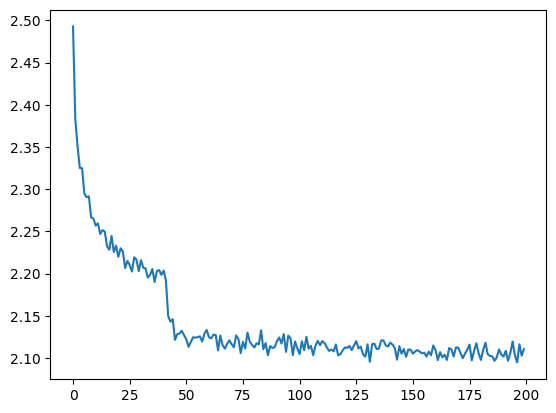

In [21]:
plt.plot(torch.tensor(loss_i).view(-1,1000).mean(dim=1));

In [22]:
for layer in model.layers:
    layer.training = False

In [23]:
@torch.no_grad()       # this decorator disable gradient tracking, (no need to calulate during evaluation)
def split_loss(split):
    x,y = {
        "train" : (x_train,y_train),
        "val"   : (x_val,y_val),
        "test"  : (x_test,y_test)
    }[split]
                                    #emb         = C[x]                      # (N,block_size,n_emb)
    logits = model(x)               #x           = emb.view(emb.shape[0],-1) # (number_of_dataset, block_size * n_emb) (N, 3 * 10)
                                    #for layer in layers:
                                    #    x = layer(x)
    loss        = F.cross_entropy(logits,y) 
    print(split,loss.item())

split_loss("train")
split_loss("val")


train 2.077577590942383
val 2.117631196975708


In [24]:
for _ in range(20):
    out     = []
    context = [0] * block_size
    while True:
        # forward pass the neural net  
        # the below step reduce the compexity of the code 
        logits  = model(torch.tensor([context]))        # 1 * vocab_size 
        probs   = F.softmax(logits,dim=1)               # 1 * vocab_size 
        # sample from distribution 
        ix      = torch.multinomial(probs,num_samples=1).item() # 1 
        # shift the context window and track the sample 
        context = context[1:] + [ix]                    
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

jeria.
nasto.
broovyn.
anustuya.
jaie.
adelei.
kenzusim.
herron.
ayie.
carden.
jinnon.
sivi.
swaa.
lyda.
armilio.
zell.
morgi.
alah.
elea.
taishora.


## Overview of WaveNet

![](https://production-media.paperswithcode.com/methods/Screen_Shot_2020-05-26_at_2.17.37_PM.png)



Currently we using this above architecture. In this architecture we are passing characters into Single hidden layer and going to predint the next character. 

**Problem Here is** 

- We cannot make this architecture in a bigger productive way, even tho if we increase the number of hidden layer and all is still crushing all the characters into a single layer. 
- if we make this bigger layer and add neurons  its still kind of like squash the all information so fast in a single step. 

- So lets introduce New Architecture name called as **WaveNet Architecture** 

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*0TbaaX8l86ghbGEhuSjPzw.jpeg)

- In this, take 2 characters and fuse them and so on (progressive fussion).

- The progressive fusion model, the model is going to deeper. In each level fuse new 2 consecutive elements. 

## Building Dataset

In [16]:
def build_dataset(dataset:list=None,block_size:int=8):   # change the block size to 8 from 3 

    X,Y = [],[]
    for word in dataset:

        context = [0] * block_size
        for char in word +".":
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx] # crop and append
    
    X = torch.tensor(X,device="cuda")
    Y = torch.tensor(Y,device="cuda") 
    print(X.shape,Y.shape)
    return X,Y


random.seed(42)
random.shuffle(words,random=random.seed(42))
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

x_train,y_train = build_dataset(words[:n1])
x_val,y_val     = build_dataset(words[n1:n2])
x_test,y_test   = build_dataset(words[n2:]) 

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [17]:
for x,y in zip(x_train[:20],y_train[:20]):
    print("".join(itos[idx.item()] for idx in x),"--->",itos[y.item()])

........ ---> e
.......e ---> b
......eb ---> r
.....ebr ---> i
....ebri ---> m
...ebrim ---> a
..ebrima ---> .
........ ---> h
.......h ---> i
......hi ---> l
.....hil ---> t
....hilt ---> o
...hilto ---> n
..hilton ---> .
........ ---> j
.......j ---> h
......jh ---> e
.....jhe ---> n
....jhen ---> e
...jhene ---> .


## Neural Network

In [18]:
n_embd      = 10
n_hidden    = 200
block_size  = 8
vocab_size  = len(itos)


model      = Sequential([Embeddings(vocab_size,n_embd),Flatten(),
                        Linear(n_embd*block_size,n_hidden,bias=False),BatchNormalization(dim=n_hidden),Tanh(),
                        Linear(n_hidden,vocab_size),])

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

parameters      = model.parameters()
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 22097


## Let's mimic Model Input & Output

In [19]:
ix              = torch.randint(0,x_train.shape[0],(4,)) # just take batch as 4 for example
x_batch,y_batch = x_train[ix],y_train[ix]
logits          = model([x_batch])
print(x_batch.shape)
x_batch

torch.Size([4, 8])


tensor([[ 0,  0,  0, 16,  1, 21, 12,  5],
        [ 0,  0,  0,  0,  1,  2,  1,  1],
        [ 0,  0,  0,  0,  0,  5, 12,  5],
        [ 0, 25,  5,  9, 12,  1, 14,  9]], device='cuda:0')

In [20]:
model.layers

In [21]:
model.layers[0].parameters()[0].shape   # input of embedding layer 
                                        # 27    = vocal_size 
                                        # 10    = n_embedding  

torch.Size([27, 10])

In [62]:
model.layers[0].out.shape   # output of embedding layer 
                            # 4  - numbers of batches
                            # 8  - numbers of characters 
                            # 10 - Embeddig diamension

torch.Size([4, 8, 10])

In [25]:
model.layers[1].out.shape # output of flatten 

torch.Size([4, 80])

- This is actually means, 10 diamesional embedding for all these 8 characters end up being stretched out into sinle row (len of raw is 80)

In [26]:
model.layers[2].out.shape # output of linear layer 

torch.Size([4, 200])

The above step is, 

- torch.randn(4,80) @ torch.randn(80,200) + torch.randn(200) 
- In fact we can pass high diamensional arrays or tensors.
    - torch.randn(4,5,10,80) @ torch.randn(80,200) + torch.randn(200) 
        - Result = 4,5,10,200. This means matrix multiplication is only works on last diamesion of first matrix. 
    - torch.randn(4,80) @ torch.randn(80,200) + torch.randn(200) 
        - Result = 4,200. This means matrix multiplication is only works on last diamesion of first matrix. 

In [27]:
(torch.randn(4,80) @ torch.randn(80,200) + torch.randn(200)).shape

torch.Size([4, 200])

In [28]:
(torch.randn(4,8,10) @ torch.randn(10,200) + torch.randn(200)).shape

torch.Size([4, 8, 200])

(torch.randn(4,8,10) @ torch.randn(10,200) + torch.randn(200))
- Here the diamensions (4,8,10), on left side is treated as batch diamensions, so its so use full in Neural network for calculations. 


- Consider 8 characters, 1,2,3,4,5,6,7,8. 
    - we dont want to flatten all these characters into a large 8-diamensional vector. because we dont want to multiply 80 with weight matrix.
    - Instead we want to group into 2 consecutive characters together like 
        - (1,2) (3,4) (5,6) (7,8)
        - By this method, every 2 consecutive elements flatten out and multiplied with weight matrix. 
        - All these pair of character(consecutive characters) process in parallel. Its kind of Batch Diamension. 

- In this step we dont want to come in all the 80 characters together, we only want 2 charactetrs come in on very first layer. 
- That 2 characters should be fuse together. 

- torch.randn(4,8,10) ==>> torch.randn(4,4,20)
    - 20 ->> 2 consecutive characters and embedded in 10 diamension

## Implimentation of above 

In [22]:
a = list(range(10))
a[::2]

[0, 2, 4, 6, 8]

In [30]:
a[1::2]

[1, 3, 5, 7, 9]

In [23]:
e = torch.randn(4,8,10)  # goal: want this to be (4,4,20),where consecutive 10-d vectors get concatenated.  
e.shape

torch.Size([4, 8, 10])

In [24]:
explicit = torch.cat([e[:,::2,:],e[:,1::2,:]],dim=2) # dim=2 means, concatenate is happening in 2nd diamension
#lets check the explicit matrix and e.view(4,4,20) is same or differ one 

(explicit == e.view(4,4,20)).all() ## check the all the elements from explicit and e.view() are true or not. 

## this means that explicit and e.view() are same in elementwise. 

tensor(True)

- we dont need to concatenate explicit form, we just use torch.cat([]) in dim=2. 


## Flatten 

- Build a object that helps to create 3 diamensional array and depending on how many vectors that are consecutive we want to fuse. 
- For example, consider array = torch.randn(4,8,10)
    - From the above array, 1st diamension = 4,number of characters = 8, embedding diamension = 10, 
    - lets consider consecutive_number = 4 (numbers of characters fuse together), 
        - Result should be torch.tensor(4,2,40) ==> (4,2,4*10) 

In [25]:
class FlattenConsecutive:

    def __init__(self,n): 
        self.n  = n 
    def __call__(self,x): 
        B,T,C   = x.shape
        x       = x.view(B,T//self.n,C*self.n)
        if x.shape[1]   == 1:
            x = x.squeeze(dim=1)         # remove the diamesion, here squeeze the 1st diamension only. 
        self.out    = x 
        return self.out
    def parameters(self):
        return []

## Start with 8 characters to fuse 

In [64]:
n_embd      = 10
n_hidden    = 200
block_size  = 8 
vocab_size  = len(itos)


model      = Sequential([Embeddings(vocab_size,n_embd),FlattenConsecutive(block_size),
                        Linear(n_embd*block_size,n_hidden,bias=False),BatchNormalization(dim=n_hidden),Tanh(),
                        Linear(n_hidden,vocab_size),])

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

parameters      = model.parameters()
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 22097


In [65]:
ix              = torch.randint(0,x_train.shape[0],(4,)) # just take batch as 4 for example
x_batch,y_batch = x_train[ix],y_train[ix]
logits          = model([x_batch])
print(x_batch.shape)
x_batch

torch.Size([4, 8])


tensor([[ 0,  0, 11,  5,  5, 18, 20,  8],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  8, 15, 12, 12,  9, 19],
        [ 0,  0,  0,  0,  0, 22,  5,  5]], device='cuda:0')

In [66]:
for layer in model.layers:
    print(layer.__class__.__name__, "==>>" ,tuple(layer.out.shape))

Embeddings ==>> (4, 8, 10)
FlattenConsecutive ==>> (4, 80)
Linear ==>> (4, 200)
BatchNormalization ==>> (4, 200)
Tanh ==>> (4, 200)
Linear ==>> (4, 27)


## 2 characters to fuse 

In [26]:
## lets make consecutive number = 2 instead of 8

n_embd      = 10
n_hidden    = 68    # number of neurons in the hidden layer 
block_size  = 2     # number of characters to fuse together 
vocab_size  = len(itos) 


model      = Sequential([Embeddings(vocab_size,n_embd),
                        FlattenConsecutive(block_size), Linear( n_embd   *2, n_hidden, bias = False ), BatchNormalization( dim = n_hidden), Tanh(),
                        FlattenConsecutive(block_size), Linear( n_hidden *2, n_hidden, bias = False ), BatchNormalization( dim = n_hidden), Tanh(),
                        FlattenConsecutive(block_size), Linear( n_hidden *2, n_hidden, bias = False ), BatchNormalization( dim = n_hidden), Tanh(),
                        Linear(n_hidden,vocab_size),])

# Parameter initialization
with torch.no_grad():
    layers[-1].weight *= 0.1  # Last layer: make less confident

parameters      = model.parameters()
flat_parameters = [para for param_list in parameters for para in param_list]
print(f"Total numbers of parameters -->> {sum(p.numel() for p in flat_parameters)}")

for para in parameters:
    para.requires_grad = True

Total numbers of parameters -->> 22397


In [28]:
n_iter      = 200000
batch_size  = 32
loss_i      = []

for i in range(n_iter):
    # mini batch
    ix              = torch.randint(0,x_train.shape[0],(batch_size,),device="cuda") # 32 numbers between 0 to 182437==>> shape (32,)
    x_batch,y_batch = x_train[ix],y_train[ix] 
    # forward pass 
    x       = x_batch   # we only need this, because can directly pass into layers, 
    logits  = model(x)
    loss    = F.cross_entropy(logits,y_batch)
    
    #backward pass 
    for para in parameters:
        para.grad = None
    loss.backward()

    #upadate: simple SGD
    lr  = 0.1 if i < 42000 else 0.01    # step learing rate decay
    for para in parameters:
        para.data += - lr * para.grad
    
    # track loss 
    if i % 10000 == 0:
        print(f"{i:7d}/{n_iter:7d} :   {loss.item():.4f}")
    loss_i.append(loss.item())
    #break

      0/ 200000 :   3.6818
  10000/ 200000 :   2.1205
  20000/ 200000 :   2.3523
  30000/ 200000 :   2.2491
  40000/ 200000 :   1.9619
  50000/ 200000 :   2.3017
  60000/ 200000 :   1.9715
  70000/ 200000 :   2.0153
  80000/ 200000 :   2.1789
  90000/ 200000 :   2.0957
 100000/ 200000 :   2.1494
 110000/ 200000 :   2.1415
 120000/ 200000 :   2.1847
 130000/ 200000 :   2.0605
 140000/ 200000 :   2.2071
 150000/ 200000 :   2.0207
 160000/ 200000 :   2.2609
 170000/ 200000 :   2.0643
 180000/ 200000 :   1.9375
 190000/ 200000 :   2.2715


In [29]:
for layer in model.layers:
    print(layer.__class__.__name__, "==>>" ,tuple(layer.out.shape))

Embeddings ==>> (32, 8, 10)
FlattenConsecutive ==>> (32, 4, 20)
Linear ==>> (32, 4, 68)
BatchNormalization ==>> (32, 4, 68)
Tanh ==>> (32, 4, 68)
FlattenConsecutive ==>> (32, 2, 136)
Linear ==>> (32, 2, 68)
BatchNormalization ==>> (32, 2, 68)
Tanh ==>> (32, 2, 68)
FlattenConsecutive ==>> (32, 136)
Linear ==>> (32, 68)
BatchNormalization ==>> (32, 68)
Tanh ==>> (32, 68)
Linear ==>> (32, 27)


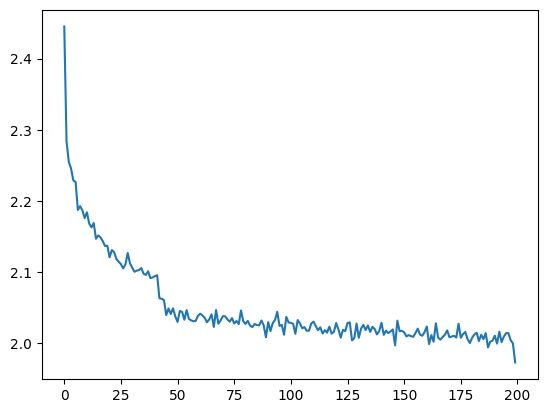

In [30]:
plt.plot(torch.tensor(loss_i).view(-1,1000).mean(dim=1));

In [31]:
for layer in model.layers:
    layer.training = False

In [32]:
@torch.no_grad()       # this decorator disable gradient tracking, (no need to calulate during evaluation)
def split_loss(split):
    x,y = {
        "train" : (x_train,y_train),
        "val"   : (x_val,y_val),
        "test"  : (x_test,y_test)
    }[split]
                                    #emb         = C[x]                      # (N,block_size,n_emb)
    logits = model(x)               #x           = emb.view(emb.shape[0],-1) # (number_of_dataset, block_size * n_emb) (N, 3 * 10)
                                    #for layer in layers:
                                    #    x = layer(x)
    loss        = F.cross_entropy(logits,y) 
    print(split,loss.item())

split_loss("train")
split_loss("val")


train 1.9708061218261719
val 2.046466588973999


In [33]:
block_size = 8 
for _ in range(20):
    out     = []
    context = [0] * block_size
    while True:
        # forward pass the neural net  
        # the below step reduce the compexity of the code 
        logits  = model(torch.tensor([context]))        # 1 * vocab_size 
        probs   = F.softmax(logits,dim=1)               # 1 * vocab_size 
        # sample from distribution 
        ix      = torch.multinomial(probs,num_samples=1).item() # 1 
        # shift the context window and track the sample 
        context = context[1:] + [ix]                    
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

adayah.
aarell.
maxhos.
yuqaius.
mylei.
terrik.
eigin.
buhim.
herran.
ayiel.
abdina.
innoo.
sivi.
semaki.
cheemmii.
ozzell.
marviella.
penda.
taishora.
thaln.
